# Single RegimeBasis on 1D Burgers
------

Tests `WeightedNeuralPODTrainer` on one viscosity file

imports:

In [ ]:
import os
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import sys, pathlib
from datasets import load_dataset
from tqdm.auto import tqdm


sys.path.insert(0, str(pathlib.Path("..").resolve()))
from models.regime_basis import RegimeBasis, FourierRegimeBasis, plot_space_time_heatmaps
from models.k_rank_neural_pod import WeightedNeuralPODTrainer, NeuralPODConfig
from models.fourier_neural_pod import FourierNeuralPODTrainer, FourierNeuralPODConfig
from models.classical_neural_pod import ClassicalNeuralPODTrainer, ClassicalNeuralPODConfig
from models.weighted_npod import plot_train_history, plot_training_loss
from utils.datasets import load

if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
DEVICE

'mps'


## Data

We use the 1D Burgers dataset from PDEBench . The Burgers equation combines nonlinear convection with viscous diffusion:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial x^2}$$

The dataset (`Burgers_Nu1.0`) contains solutions for viscosity $\nu = 1.0$, discretized on a uniform grid with $N_x = 1024$ spatial points over $x \in (-1, 1)$ and $N_t = 101$ time steps over $t \in (0, 2)$. Each of the 9500 training samples corresponds to a distinct random initial condition. 

Data is stored in HDF5 format with shape `(N, Nt, Nx, 1)`, along with coordinate arrays `x-coordinate` and `t-coordinate`


Dataset downloading:

In [3]:
data = load("Burgers_Nu0.4")

Look at the data:

In [4]:
data

{'t-coordinate': array([0.        , 0.00784314, 0.01568628, 0.02352941, 0.03137255,
        0.03921569, 0.04705882, 0.05490196, 0.0627451 , 0.07058824,
        0.07843138, 0.08627451, 0.09411765, 0.10196079, 0.10980392,
        0.11764706, 0.1254902 , 0.13333334, 0.14117648, 0.14901961,
        0.15686275, 0.16470589, 0.17254902, 0.18039216, 0.1882353 ,
        0.19607843, 0.20392157, 0.21176471, 0.21960784, 0.22745098,
        0.23529412, 0.24313726, 0.2509804 , 0.25882354, 0.26666668,
        0.27450982, 0.28235295, 0.2901961 , 0.29803923, 0.30588236,
        0.3137255 , 0.32156864, 0.32941177, 0.3372549 , 0.34509805,
        0.3529412 , 0.36078432, 0.36862746, 0.3764706 , 0.38431373,
        0.39215687, 0.4       , 0.40784314, 0.41568628, 0.42352942,
        0.43137255, 0.4392157 , 0.44705883, 0.45490196, 0.4627451 ,
        0.47058824, 0.47843137, 0.4862745 , 0.49411765, 0.5019608 ,
        0.50980395, 0.5176471 , 0.5254902 , 0.53333336, 0.5411765 ,
        0.54901963, 0.5568628 , 

Extracting data:

In [5]:
tensor = data["tensor"]    # (N, Nt, Nx, 1)
x = data["x-coordinate"]   # (Nx,)
t = data["t-coordinate"]   # (Nt,)
u = tensor[:, :, :, 0]     # (N, Nt, Nx)
 
N, Nt, Nx = u.shape
print(f"N={N}, Nt={Nt}, Nx={Nx},  x: [{x[0]:.2f}, {x[-1]:.2f}],  t: [{t[0]:.2f}, {t[-1]:.2f}]")

N=9500, Nt=256, Nx=101,  x: [-1.00, 1.00],  t: [0.00, 2.00]


visualization:

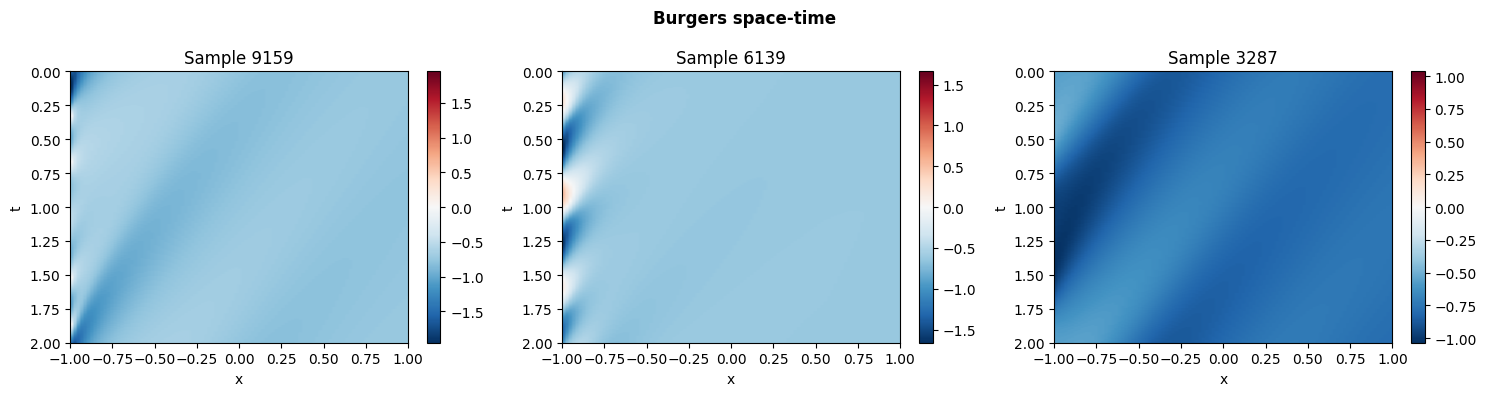

In [6]:
samples = np.random.choice(N, size=3, replace=False)
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, si in zip(axes, samples):
    vmax = np.abs(u[si]).max()
    im = ax.imshow(
        u[si], aspect="auto",
        extent=[x[0], x[-1], t[-1], t[0]],
        cmap="RdBu_r", vmin=-vmax, vmax=vmax,
    )
    ax.set_title(f"Sample {si}")
    ax.set_xlabel("x"); ax.set_ylabel("t")
    plt.colorbar(im, ax=ax, fraction=0.046)
 
fig.suptitle("Burgers space-time", fontweight="bold")
fig.tight_layout()
plt.show()

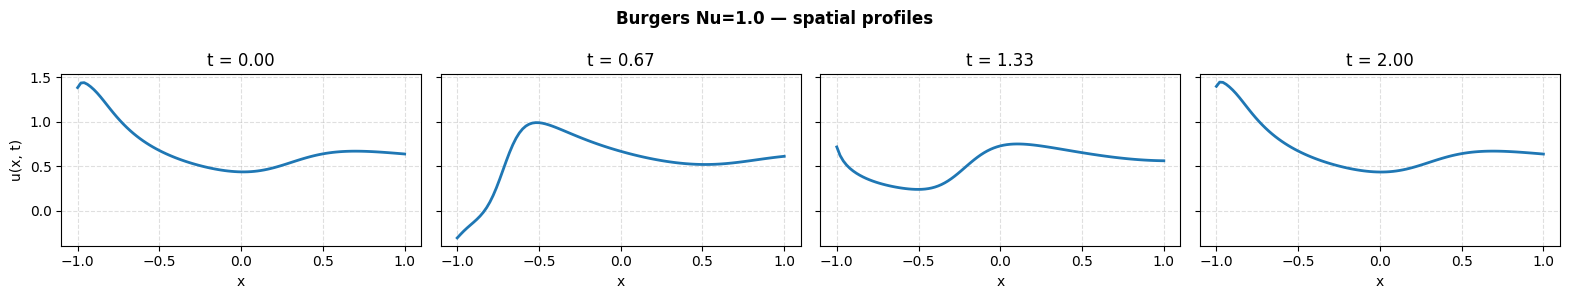

In [7]:
t_ids = [0, Nt // 3, 2 * Nt // 3, Nt - 1]
 
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
for ax, ti in zip(axes, t_ids):
    ax.plot(x, u[0, ti], lw=2)
    ax.set_title(f"t = {t[ti]:.2f}")
    ax.set_xlabel("x")
    ax.grid(True, ls="--", alpha=0.4)
 
axes[0].set_ylabel("u(x, t)")
fig.suptitle("Burgers Nu=1.0 — spatial profiles", fontweight="bold")
fig.tight_layout()
plt.show()

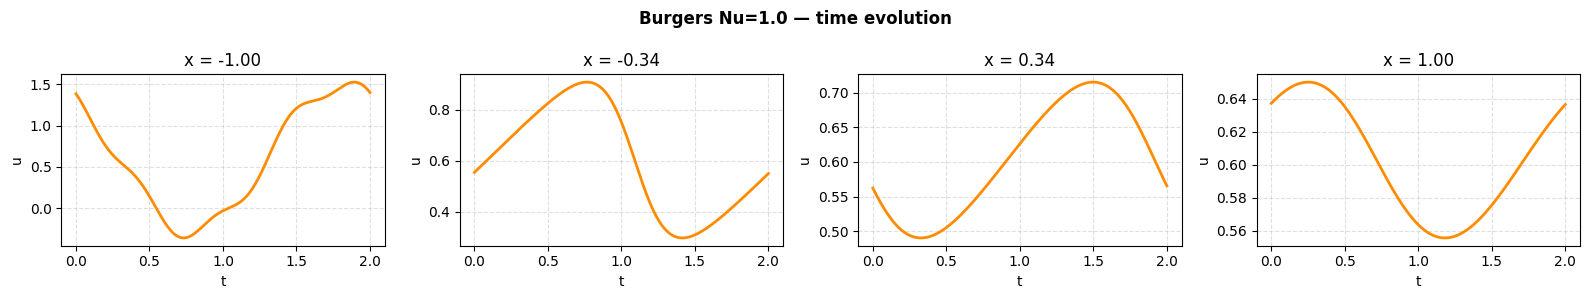

In [8]:
x_ids = [0, Nx // 3, 2 * Nx // 3, Nx - 1]
 
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, xi in zip(axes, x_ids):
    ax.plot(t, u[0, :, xi], lw=2, color="darkorange")
    ax.set_title(f"x = {x[xi]:.2f}")
    ax.set_xlabel("t"); ax.set_ylabel("u")
    ax.grid(True, ls="--", alpha=0.4)
 
fig.suptitle("Burgers Nu=1.0 — time evolution", fontweight="bold")
fig.tight_layout()
plt.show()

## Training

Take 64 samples, downsample x by 8x (1024 -> 128), drop channel dim:

In [9]:
tensor = data["tensor"][:64, :, ::16, 0] 
x_np  = data["x-coordinate"][::16]
t_np = data["t-coordinate"]
N, Nt, Nx = tensor.shape
NU = 1.0

In [11]:
#tensor = data["tensor"][:, :, :, 0]
#x_np   = data["x-coordinate"][:]
#t_np   = data["t-coordinate"]
#N, Nt, Nx = tensor.shape
#NU = 1.0

Each (sample, timestep) pair becomes one snapshot:

In [11]:
s = torch.tensor(tensor.reshape(-1, Nx), dtype=torch.float32)
t = torch.tensor(np.tile(t_np, N), dtype=torch.float32)
x = torch.tensor(x_np[:, None], dtype=torch.float32)
kappa = torch.full((len(s), 1), NU, dtype=torch.float32)
gamma = torch.ones(len(s), dtype=torch.float32) / len(s)

s, t, x, kappa, gamma = [v.to(DEVICE) for v in [s, t, x, kappa, gamma]]
print(f"s={s.shape}, t={t.shape}, x={x.shape}")

s=torch.Size([16384, 7]), t=torch.Size([16384]), x=torch.Size([7, 1])


## Classical NeuralPOD

In [11]:
Ny = x.shape[0]
N = s.shape[0]

In [ ]:
N_samples = 5    # 5  initial conditions
tensor = data["tensor"][:N_samples, :, :, 0]  # (5, 256, 1024) - og resolution
x_np = data["x-coordinate"][:]                # (1024,)
t_np = data["t-coordinate"]                   # (256,)

N, Nt, Nx = tensor.shape  # N=5, Nt=256, Nx=1024

s = torch.tensor(tensor.reshape(-1, Nx), dtype=torch.float32)  # (1280, 1024)
t = torch.tensor(np.tile(t_np, N), dtype=torch.float32)         # (1280,)
x = torch.tensor(x_np[:, None], dtype=torch.float32)            # (1024, 1)

print(f"s={s.shape}, t={t.shape}, x={x.shape}")

s=torch.Size([1280, 101]), t=torch.Size([1280]), x=torch.Size([101, 1])


Config:

In [13]:
cfg = ClassicalNeuralPODConfig(
    tol=1e-3,        # Остановиться когда ошибка < 0.1%
    lr=5e-4,
    max_modes=5,     # Макс 5 мод
    n_epochs=100,    # 100 эпох на каждую моду
    batch_size=32,
    log_every=10,
    hidden_dim=64,
    n_layers=2,
)

In [ ]:
trainer_classical = ClassicalNeuralPODTrainer(cfg)

In [15]:
history = trainer_classical.train(s, x, t)

# Предсказание
s_pred = trainer_classical.predict(x, t).cpu().detach().numpy()
s_np = s.cpu().numpy()
rel_err = np.linalg.norm(s_np - s_pred) / np.linalg.norm(s_np)


Classical NeuralPOD (Greedy Training)
Data: N=1280 snapshots, Ny=101 spatial points, d_x=1
Tolerance (absolute): 3.614356e-04

Mode 1: residual_norm = 3.614356e-01


  training:   0%|          | 0/100 [00:00<?, ?it/s]

  → after mode: residual_norm = 2.859715e-01

Mode 2: residual_norm = 2.859715e-01


  training:   0%|          | 0/100 [00:00<?, ?it/s]

  → after mode: residual_norm = 2.841703e-01

Mode 3: residual_norm = 2.841703e-01


...

  → after mode: residual_norm = 2.841701e-01

Mode 4: residual_norm = 2.841701e-01


  training:   0%|          | 0/100 [00:00<?, ?it/s]

  → after mode: residual_norm = 2.839220e-01

Mode 5: residual_norm = 2.839220e-01


  training:   0%|          | 0/100 [00:00<?, ?it/s]

  → after mode: residual_norm = 2.839207e-01

Training complete: 5 modes trained




✅ Trained 5 modes
Relative L2 error: 0.8863



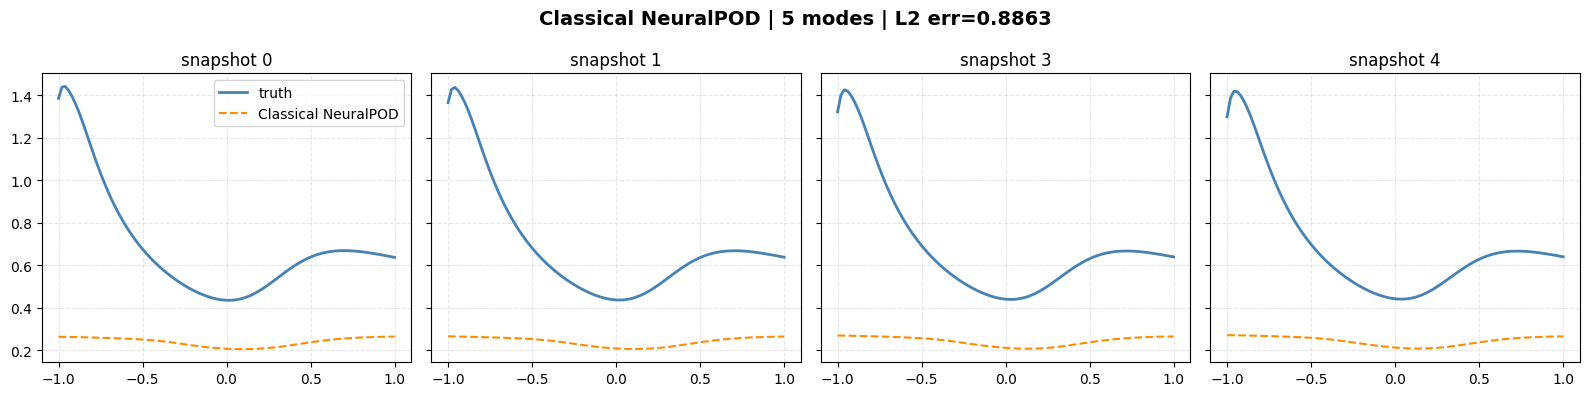

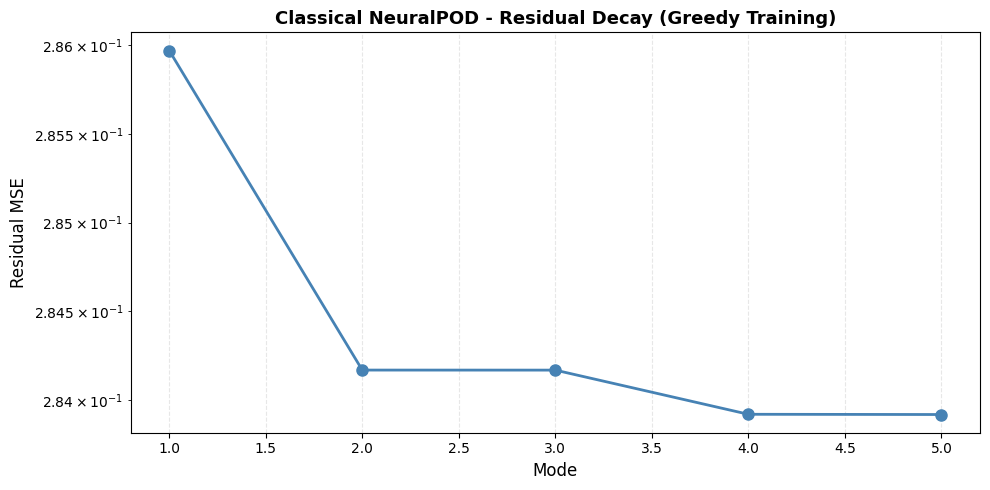

In [ ]:
print(f"\nTrained {len(trainer_classical.modes)} modes")
print(f"Relative L2 error: {rel_err:.4f}\n")


fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, idx in zip(axes, [0, N//3, 2*N//3, N-1]):
    ax.plot(x.cpu().numpy(), s_np[idx], lw=2, label="truth", color="steelblue")
    ax.plot(x.cpu().numpy(), s_pred[idx], lw=1.5, ls="--", label="Classical NeuralPOD", color="darkorange")
    ax.set_title(f"snapshot {idx}")
    ax.grid(True, ls="--", alpha=0.3)
axes[0].legend()
plt.suptitle(f"Classical NeuralPOD | {len(trainer_classical.modes)} modes | L2 err={rel_err:.4f}", 
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
if history.residual_norms:
    ax.semilogy(range(1, len(history.residual_norms)+1), history.residual_norms, 
                'o-', linewidth=2, markersize=8, color='steelblue')
    ax.set_xlabel('Mode', fontsize=12)
    ax.set_ylabel('Residual MSE', fontsize=12)
    ax.set_title('Classical NeuralPOD - Residual Decay (Greedy Training)', fontsize=13, fontweight='bold')
    ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

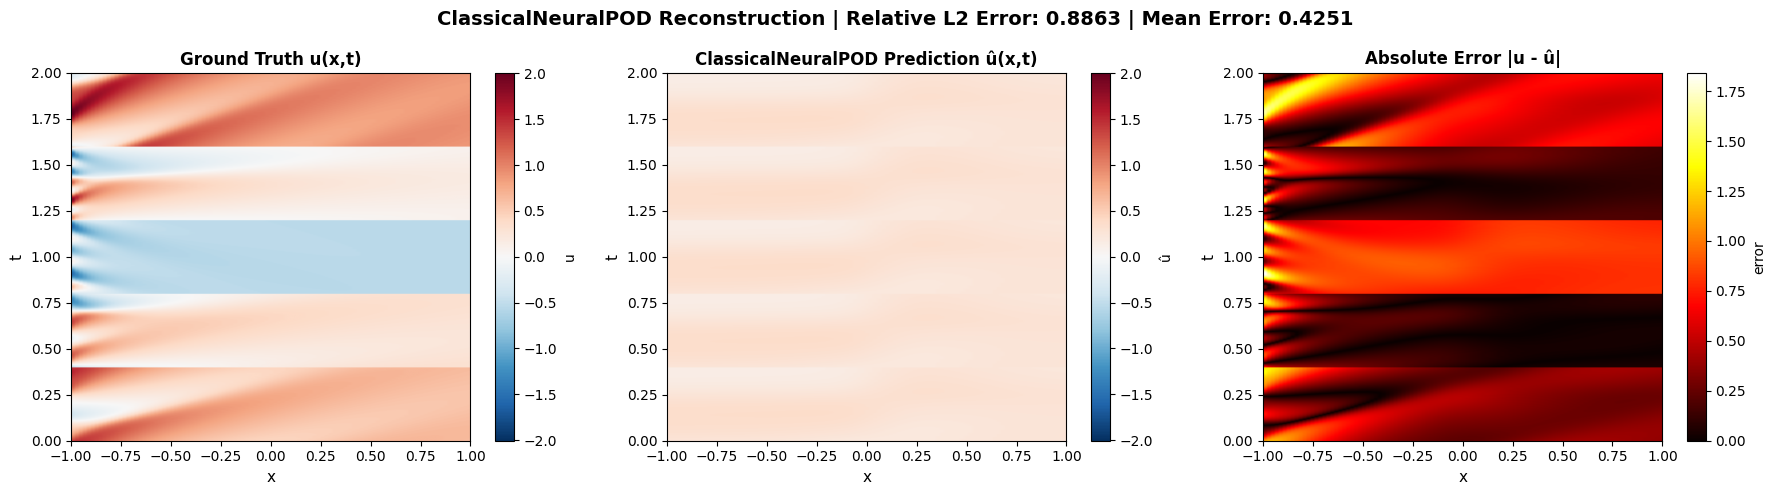

In [17]:
fig = plot_space_time_heatmaps(trainer_classical, s, x, t, "ClassicalNeuralPOD")
plt.show()

## Article

init basis:

In [18]:
quad_w = torch.full((Nx,), 1.0/Nx, dtype=torch.float32, device=DEVICE)
basis   = RegimeBasis(d_x=1, d_kappa=1, quad_weights=quad_w, K=8, hidden_dim=64).to(DEVICE)


data scale:

In [19]:
s_norm = basis._weighted_norm_sq(s, gamma).item()
print(f"Initial weighted norm of s: {s_norm:.4f}")

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu!

init trainer:

In [ ]:

Ny = x.shape[0]
N = s.shape[0] 


quad_w = torch.full((Ny,), 1.0/Ny, dtype=torch.float32, device=DEVICE)
basis_authors = RegimeBasis(d_x=1, d_kappa=1, quad_weights=quad_w, K=8, hidden_dim=64).to(DEVICE)

cfg = NeuralPODConfig(
    lr=5e-4,
    K=8,
    n_epochs=100,
    batch_size=32,
    grad_clip_norm=1.0,
    log_every=5,
    lambda_basis=1.0
)

trainer_authors = WeightedNeuralPODTrainer(basis_authors, cfg)


history_authors = trainer_authors.train(s, x, t, kappa, gamma)


basis_authors.eval()
with torch.no_grad():
    s_pred = basis_authors(x, t, kappa).cpu().numpy()

s_np = s.cpu().numpy()
rel_err = np.linalg.norm(s_np - s_pred) / np.linalg.norm(s_np)
print(f"\nRelative L2 error: {rel_err:.4f}")


fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, ti in zip(axes, [0, N//3, 2*N//3, N-1]):
    ax.plot(x.cpu().numpy(), s_np[ti], lw=2, label="truth")
    ax.plot(x.cpu().numpy(), s_pred[ti], lw=1.5, ls="--", label="pred (authors)")
    ax.set_title(f"snapshot {ti}")
    ax.grid(True, ls="--", alpha=0.4)
axes[0].legend()
plt.suptitle(f"Authors' Approach | L2 err={rel_err:.4f}", fontweight="bold")
plt.tight_layout()
plt.show()

plot_train_history(trainer_authors)
plt.show()


In [ ]:
cfg     = NeuralPODConfig()
trainer_pod = WeightedNeuralPODTrainer(basis, cfg)

training:

In [ ]:
history = trainer_pod.train(s, x, t, kappa, gamma)

training:   0%|          | 0/2000 [00:00<?, ?it/s]


Weight initialization (authors' reciprocal weighting):
  L_data_init = 3.893191e-01, w_data = 2.568587e+00
  L_basis_init = 5.643444e-01, w_basis = 1.771968e+00



KeyboardInterrupt: 

In [ ]:
basis.eval()
with torch.no_grad():
    s_hat = basis(x, t, kappa).cpu().numpy()

s_np = s.cpu().numpy()
rel_err = np.linalg.norm(s_np - s_hat) / np.linalg.norm(s_np)
print(f"Relative L2 error: {rel_err:.4f}")

Relative L2 error: 0.9708


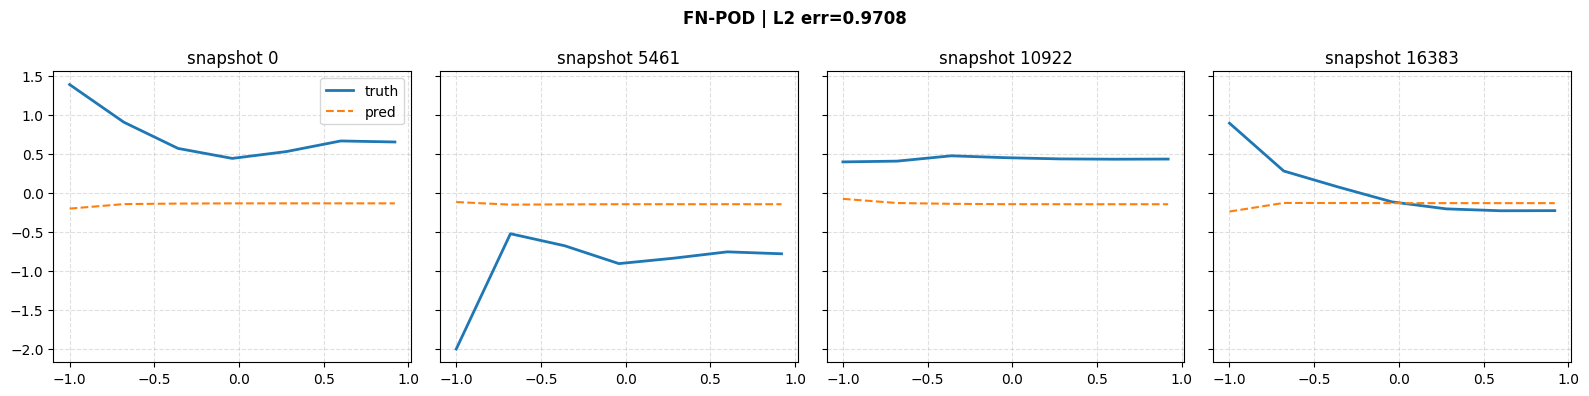

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, ti in zip(axes, [0, N//3, 2*N//3, N-1]):
    ax.plot(x.cpu().numpy(), s_np[ti], lw=2, label="truth")
    ax.plot(x.cpu().numpy(), s_hat[ti], lw=1.5, ls="--", label="pred")
    ax.set_title(f"snapshot {ti}"); ax.grid(True, ls="--", alpha=0.4)
axes[0].legend()
plt.suptitle(f"FN-POD | L2 err={rel_err:.4f}", fontweight="bold")
plt.tight_layout()
plt.show()

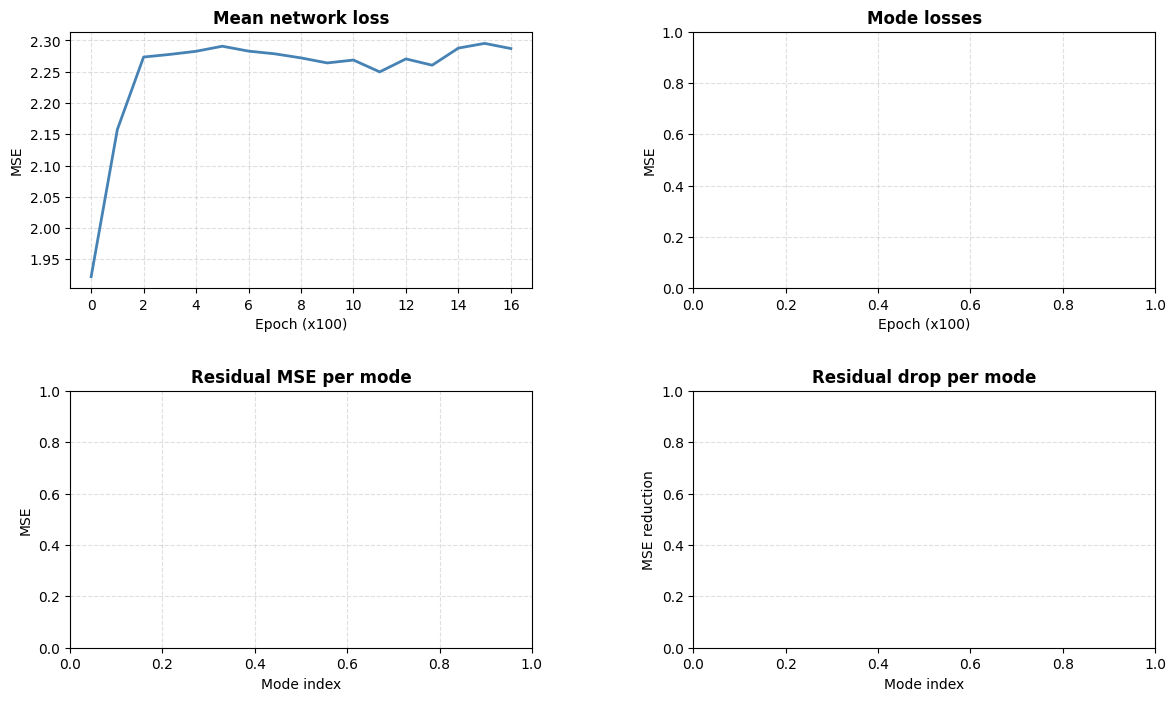

In [ ]:
plot_train_history(trainer_pod)
plt.show()

In [ ]:
plot_space_time_heatmaps(basis, s, x, t)
plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'

## Neural Fourier POD

In [12]:
N = s.shape[0]
Ny = x.shape[0]

new basis:

In [13]:
quad_w = torch.full((Ny,), 1.0/Ny, dtype=torch.float32, device=DEVICE)
basis = FourierRegimeBasis(d_x=1, M=N, quad_weights=quad_w).to(DEVICE)

trainer config:

In [14]:
cfg = FourierNeuralPODConfig(n_epochs_mean = 1000, n_epochs_mode = 500)
trainer_fourier = FourierNeuralPODTrainer(basis, cfg)

training:

In [15]:
history = trainer_fourier.train(s, x, t, kappa, gamma)

mean:   0%|          | 0/1000 [00:00<?, ?it/s]

mode 1:   0%|          | 0/500 [00:00<?, ?it/s]

mode 2:   0%|          | 0/500 [00:00<?, ?it/s]

mode 3:   0%|          | 0/500 [00:00<?, ?it/s]

mode 4:   0%|          | 0/500 [00:00<?, ?it/s]

mode 5:   0%|          | 0/500 [00:00<?, ?it/s]

Error:

In [16]:
basis.eval()
with torch.no_grad():
    s_hat = basis(x, t, kappa).cpu().numpy()

s_np = s.cpu().numpy()
rel_err = np.linalg.norm(s_np - s_hat) / np.linalg.norm(s_np)
print(f"Relative L2 error: {rel_err:.4f}")

Relative L2 error: 0.1172


visualization:

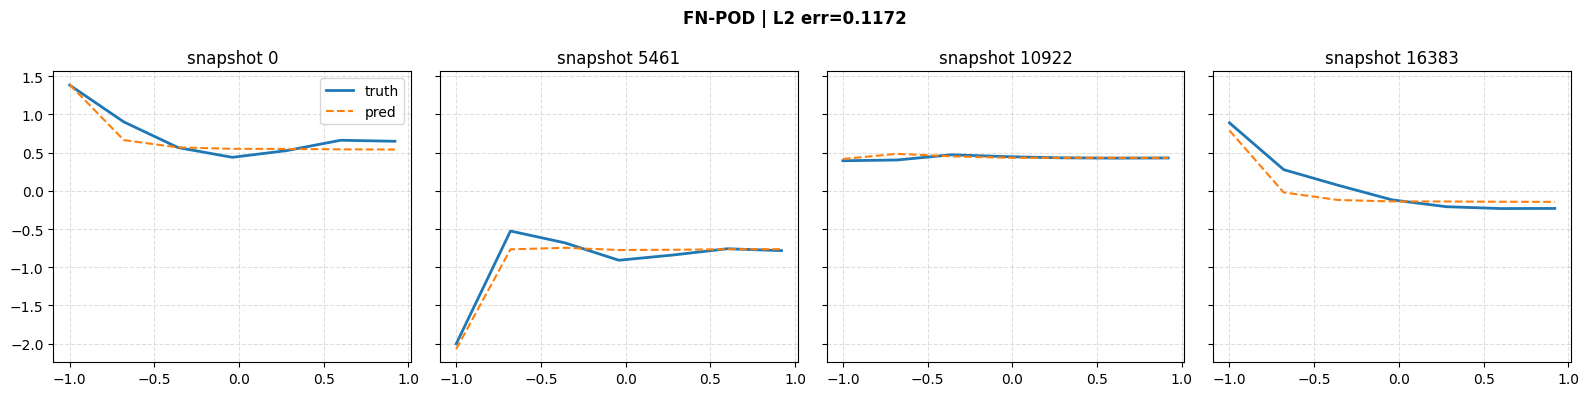

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, ti in zip(axes, [0, N//3, 2*N//3, N-1]):
    ax.plot(x.cpu().numpy(), s_np[ti], lw=2, label="truth")
    ax.plot(x.cpu().numpy(), s_hat[ti], lw=1.5, ls="--", label="pred")
    ax.set_title(f"snapshot {ti}"); ax.grid(True, ls="--", alpha=0.4)
axes[0].legend()
plt.suptitle(f"FN-POD | L2 err={rel_err:.4f}", fontweight="bold")
plt.tight_layout()
plt.show()

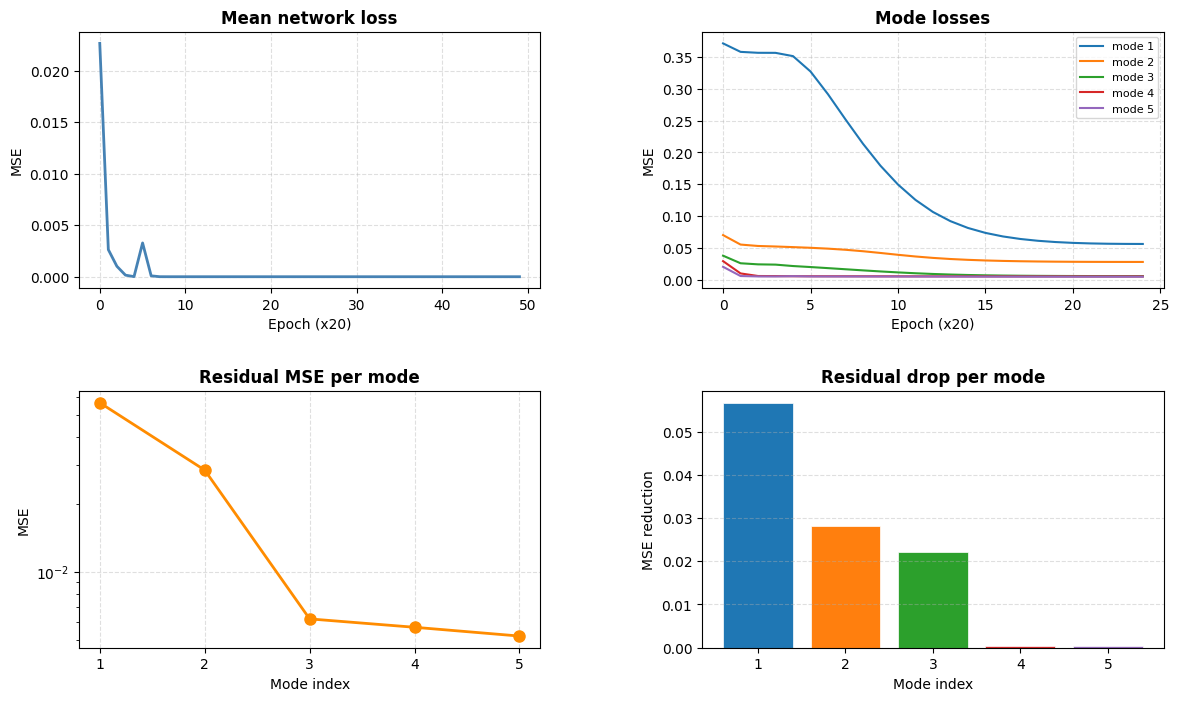

In [18]:
plot_train_history(trainer_fourier)
plt.show()

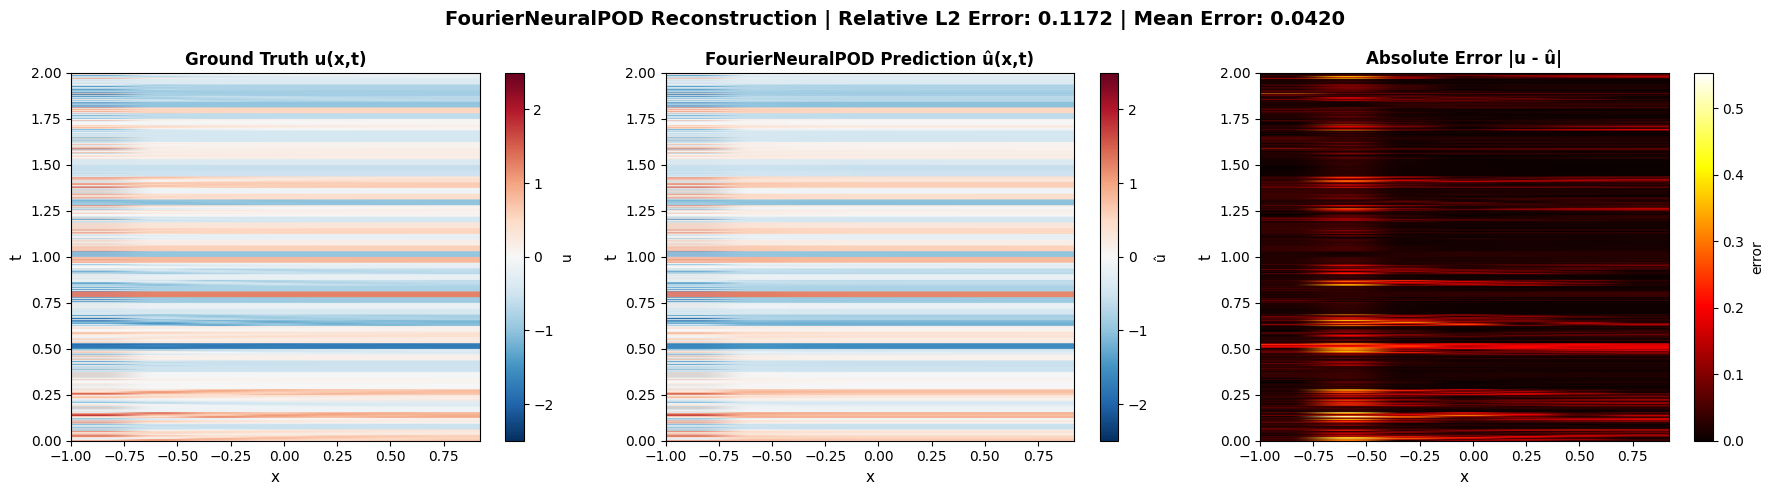

In [19]:
fig = plot_space_time_heatmaps(trainer_fourier, s, x, t, "FourierNeuralPOD")
plt.show()

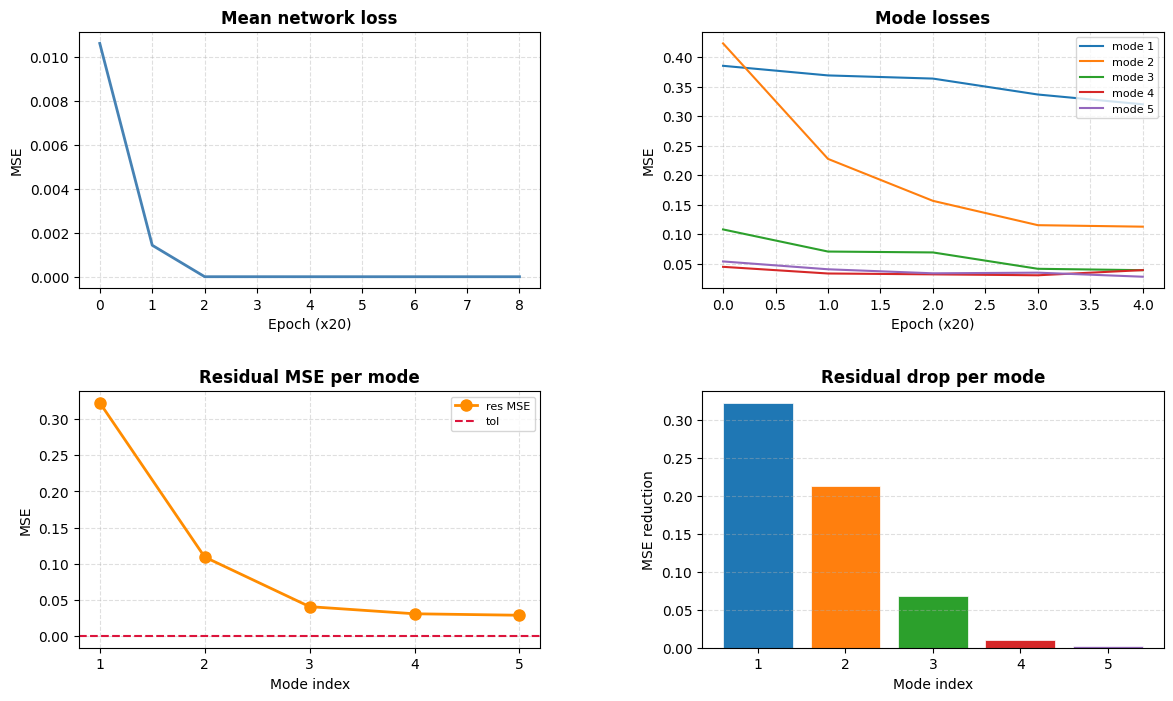

In [ ]:
plot_train_history(trainer_fourier)
plt.show()

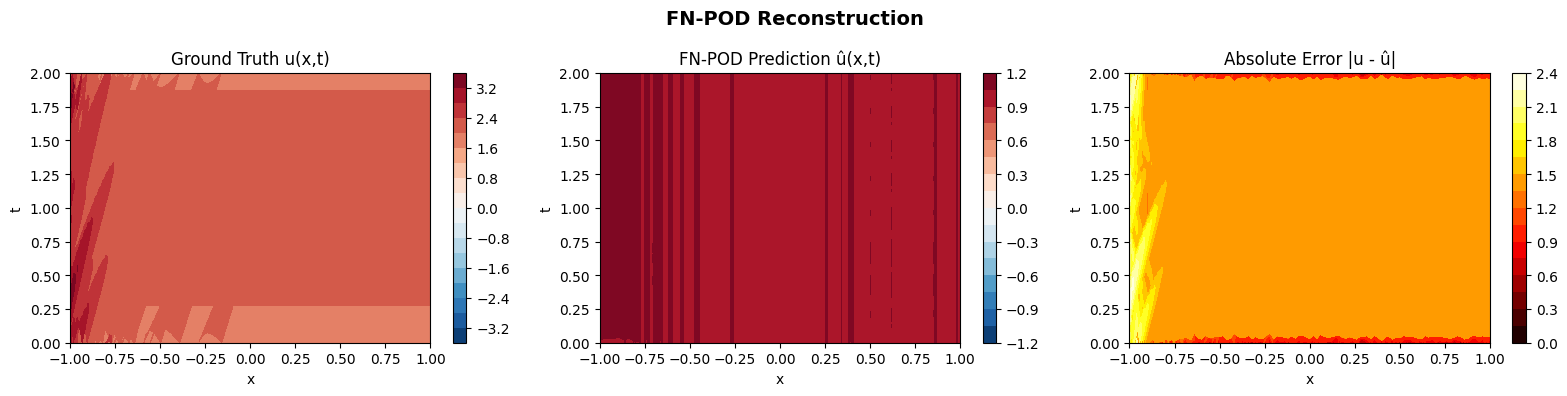

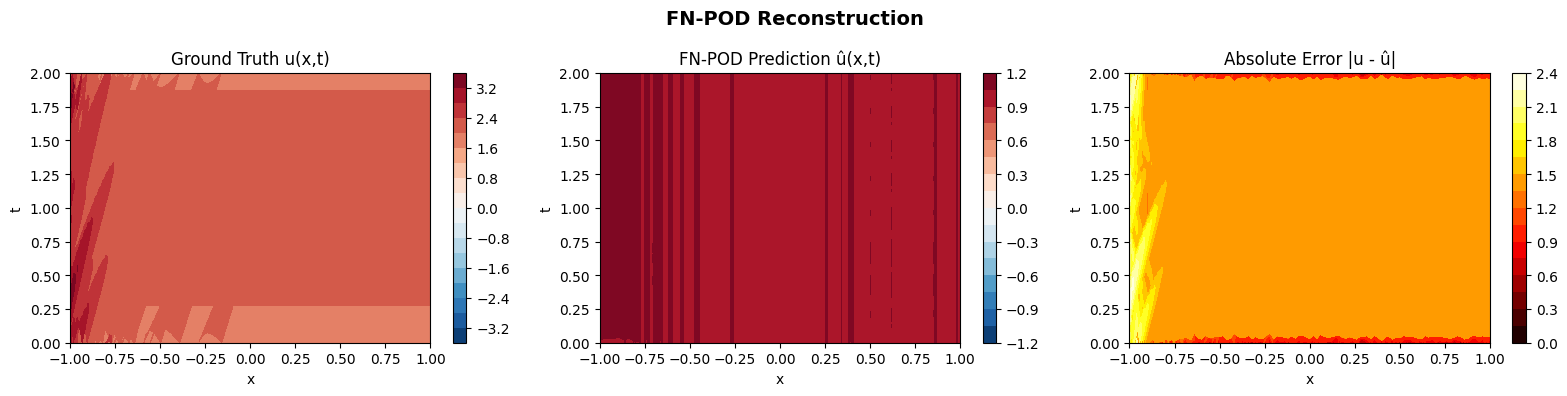

In [ ]:
fig = plot_space_time_heatmaps(trainer_fourier, s, x, t, "FourierNeuralPOD")
plt.show()